# PART 1 - Data Collection

In [1]:
import requests
import pandas as pd
import time
import logging

# logging
logging.basicConfig(
    filename="nba_scraper.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

url = "https://stats.nba.com/stats/leaguedashplayerstats"

headers = {
    "User-Agent": "Mozilla/5.0",
    "Referer": "https://www.nba.com/",
    "Accept": "application/json, text/plain, */*"
}

#  seasons generation 2000-01 → 2024-25
seasons = [f"{year}-{str(year+1)[-2:]}" for year in range(2000, 2025)]

all_data = []

for season in seasons:
    logging.info(f"Starting season {season}")
    print(f"Processing {season}...")

    params = {
        "Season": season,
        "SeasonType": "Regular Season",
        "PerMode": "PerGame",
        "LeagueID": "00"
    }

    for attempt in range(3):
        try:
            response = requests.get(url, headers=headers, params=params, timeout=10)
            response.raise_for_status()

            data = response.json()

            # convert to DataFrame
            headers_data = data['resultSets'][0]['headers']
            rows = data['resultSets'][0]['rowSet']

            df = pd.DataFrame(rows, columns=headers_data)
            df['SEASON'] = season  # adding new season

            all_data.append(df)

            logging.info(f"Season {season} loaded: {len(df)} rows")
            print(f"{season} done")

            time.sleep(1)  # rate limiting
            break

        except requests.exceptions.RequestException as e:
            logging.error(f"{season} attempt {attempt+1} failed: {e}")
            print(f"Error on {season}, attempt {attempt+1}")
            time.sleep(2)

# joining all
df_raw = pd.concat(all_data, ignore_index=True)

# saving
df_raw.to_csv("nba_raw_data_2000_2025.csv", index=False)

print("All seasons collected!")
print("Shape:", df_raw.shape)

KeyboardInterrupt: 

In [1]:
import pandas as pd
import time
import logging
from nba_api.stats.endpoints import leaguedashplayerstats

# ---------------- LOGGING ----------------
logging.basicConfig(
    filename="scraper.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

# ---------------- CONFIG ----------------
seasons = [f"{year}-{str(year+1)[-2:]}" for year in range(2000, 2025)]
all_data = []

# ---------------- SCRAPING ----------------
for season in seasons:
    try:
        logging.info(f"Starting season {season}")
        print(f"Processing {season}...")

        stats = leaguedashplayerstats.LeagueDashPlayerStats(
            season=season,
            per_mode_detailed='PerGame'
        )

        df = stats.get_data_frames()[0]
        df['SEASON'] = season

        all_data.append(df)

        logging.info(f"Success {season} | rows: {len(df)}")
        print(f"{season} done")

        time.sleep(1.5)

    except Exception as e:
        logging.error(f"Error in season {season}: {e}")
        print(f"Error in {season}")

# ---------------- SAVE RAW DATA ----------------
df_raw = pd.concat(all_data, ignore_index=True)

df_raw.to_csv("nba_raw_data_2000_2025.csv", index=False)

logging.info(f"Saved dataset with {len(df_raw)} rows")

print("All seasons collected!")
print("Shape:", df_raw.shape)

🎉 All seasons collected!
Shape: (12228, 68)


In [2]:
import pandas as pd
df_raw = pd.read_csv('123_dataset.csv')

# PART 2 - Data Cleaning and Preprocessing

In [3]:
# ---------------- CHECKING RAW DATA ----------------
print(df_raw.columns)
# ---------------- CHOOSING ONLY USEFUL COLUMNS ----------------
df_cleaned = df_raw[[
    'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM',
    'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT',
    'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS',
    'DD2', 'TD3', 'SEASON']]

Index(['PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'W', 'L', 'W_PCT',
       'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA',
       'FT_PCT', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS',
       'PLUS_MINUS', 'DD2', 'TD3', 'SEASON', 'PTS_PER_MIN', 'EFF',
       'SHOT_VOLUME'],
      dtype='str')


In [4]:
# ---------------- STRUCTURE OF RAW DATA ----------------
print(df_raw.head())

      PLAYER_NAME TEAM_ABBREVIATION   AGE  GP   W   L  W_PCT   MIN  FGM  FGA  \
0      A.C. Green               MIA  37.0  82  50  32  0.610  17.2  1.8  4.0   
1     A.J. Guyton               CHI  23.0  33   6  27  0.182  19.0  2.4  5.8   
2     Aaron McKie               PHI  28.0  76  51  25  0.671  31.5  4.4  9.4   
3  Aaron Williams               NJN  29.0  82  26  56  0.317  28.5  3.6  7.9   
4      Adam Keefe               GSW  31.0  67  14  53  0.209  12.6  1.0  2.4   

   ...   PF  PFD   PTS  PLUS_MINUS  DD2  TD3   SEASON  PTS_PER_MIN       EFF  \
0  ...  1.5  0.0   4.5         1.3    3    0  2000-01     0.261628  0.482558   
1  ...  1.1  0.0   6.0        -4.4    0    0  2000-01     0.315789  0.436842   
2  ...  2.3  0.0  11.6         4.4    8    2  2000-01     0.368254  0.571429   
3  ...  3.9  0.0  10.2        -4.6   12    0  2000-01     0.357895  0.592982   
4  ...  1.5  0.0   2.5        -2.6    0    0  2000-01     0.198413  0.436508   

   SHOT_VOLUME  
0          5.4  
1   

In [5]:
# ---------------- HANDLING MISSING VALUES ----------------
print(df_cleaned.isnull().sum())

PLAYER_NAME          0
TEAM_ABBREVIATION    0
AGE                  0
GP                   0
W                    0
L                    0
W_PCT                0
MIN                  0
FGM                  0
FGA                  0
FG_PCT               0
FG3M                 0
FG3A                 0
FG3_PCT              0
FTM                  0
FTA                  0
FT_PCT               0
REB                  0
AST                  0
TOV                  0
STL                  0
BLK                  0
BLKA                 0
PF                   0
PFD                  0
PTS                  0
PLUS_MINUS           0
DD2                  0
TD3                  0
SEASON               0
dtype: int64


In [6]:
# ---------------- HANDLING DUPLICATED ROWS ----------------
print(df_cleaned.duplicated(subset=['PLAYER_NAME', 'SEASON']).sum())
print(df_cleaned[df_cleaned.duplicated(subset=['PLAYER_NAME', 'SEASON'])])

0
Empty DataFrame
Columns: [PLAYER_NAME, TEAM_ABBREVIATION, AGE, GP, W, L, W_PCT, MIN, FGM, FGA, FG_PCT, FG3M, FG3A, FG3_PCT, FTM, FTA, FT_PCT, REB, AST, TOV, STL, BLK, BLKA, PF, PFD, PTS, PLUS_MINUS, DD2, TD3, SEASON]
Index: []

[0 rows x 30 columns]


In [7]:
# ---------------- HANDLING DUPLICATED ROWS ----------------
df_duplicated = df_cleaned.copy()
df_duplicated = df_duplicated.drop_duplicates(subset=['PLAYER_NAME', 'SEASON'])

In [8]:
# ---------------- HANDLING DUPLICATED ROWS ----------------
print(df_duplicated.duplicated(subset=['PLAYER_NAME', 'SEASON']).sum())

0


In [9]:
# ---------------- INSPECTING DATA TYPES ----------------
df_duplicated['TEAM_ABBREVIATION'] = df_duplicated['TEAM_ABBREVIATION'].astype('category')
df_duplicated['SEASON'] = df_duplicated['SEASON'].astype('category')

In [10]:
# ---------------- INSPECTING DATA TYPES ----------------
print(df_duplicated.dtypes)

PLAYER_NAME               str
TEAM_ABBREVIATION    category
AGE                   float64
GP                      int64
W                       int64
L                       int64
W_PCT                 float64
MIN                   float64
FGM                   float64
FGA                   float64
FG_PCT                float64
FG3M                  float64
FG3A                  float64
FG3_PCT               float64
FTM                   float64
FTA                   float64
FT_PCT                float64
REB                   float64
AST                   float64
TOV                   float64
STL                   float64
BLK                   float64
BLKA                  float64
PF                    float64
PFD                   float64
PTS                   float64
PLUS_MINUS            float64
DD2                     int64
TD3                     int64
SEASON               category
dtype: object


# PART 3 - Data Transformation & Feature Engineering

In [11]:
# ---------------- CREATING NEW FEATURES ----------------
df_analysis = df_duplicated.copy()
df_analysis['PTS_PER_MIN'] = df_analysis['PTS'] / df_analysis['MIN']

df_analysis['EFF'] = (df_analysis['PTS'] + df_analysis['REB'] + df_analysis['AST'] - df_analysis['TOV']) / df_analysis['MIN']

df_analysis['SHOT_VOLUME'] = df_analysis['FGA'] + df_analysis['FTA']

In [12]:
# ---------------- CHECKING AFTER ALL STEPS ----------------
print(df_analysis)

           PLAYER_NAME TEAM_ABBREVIATION   AGE  GP   W   L  W_PCT   MIN  FGM  \
0           A.C. Green               MIA  37.0  82  50  32  0.610  17.2  1.8   
1          A.J. Guyton               CHI  23.0  33   6  27  0.182  19.0  2.4   
2          Aaron McKie               PHI  28.0  76  51  25  0.671  31.5  4.4   
3       Aaron Williams               NJN  29.0  82  26  56  0.317  28.5  3.6   
4           Adam Keefe               GSW  31.0  67  14  53  0.209  12.6  1.0   
...                ...               ...   ...  ..  ..  ..    ...   ...  ...   
12219      Zach LaVine               SAC  30.0  74  32  42  0.432  35.2  8.4   
12220       Zeke Nnaji               DEN  24.0  57  36  21  0.632  10.7  1.2   
12221  Ziaire Williams               BKN  23.0  63  22  41  0.349  24.5  3.4   
12222  Zion Williamson               NOP  24.0  30  10  20  0.333  28.6  9.6   
12223      Zyon Pullin               MEM  24.0   3   1   2  0.333   0.9  0.0   

        FGA  ...   PF  PFD   PTS  PLUS_

In [13]:
# ---------------- SAVE CLEAN DATA ----------------
df_analysis.to_csv('nba_clean_data_2000_2025.csv', index=False)

# PART 4 -  Exploratory Data Analysis (EDA) & Visualization

In [14]:
# ---------------- IMPORT LIBRARIES FOR NEXT STEP ----------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
# ---------------- LOADING DATASET FOR NEXT STEP ----------------
df = pd.read_csv('nba_clean_data_2000_2025.csv')
print('Shape:', df.shape)
df.head()

,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,...,PF,PFD,PTS,PLUS_MINUS,DD2,TD3,SEASON,PTS_PER_MIN,EFF,SHOT_VOLUME
0,A.C. Green,MIA,37.0,82,50,32,0.610,17.2,1.8,4.0,...,1.5,0.0,4.5,1.3,3,0,2000-01,0.261628,0.482558,5.4
1,A.J. Guyton,CHI,23.0,33,6,27,0.182,19.0,2.4,5.8,...,1.1,0.0,6.0,-4.4,0,0,2000-01,0.315789,0.436842,6.3
2,Aaron McKie,PHI,28.0,76,51,25,0.671,31.5,4.4,9.4,...,2.3,0.0,11.6,4.4,8,2,2000-01,0.368254,0.571429,12.0
3,Aaron Williams,NJN,29.0,82,26,56,0.317,28.5,3.6,7.9,...,3.9,0.0,10.2,-4.6,12,0,2000-01,0.357895,0.592982,11.7
4,Adam Keefe,GSW,31.0,67,14,53,0.209,12.6,1.0,2.4,...,1.5,0.0,2.5,-2.6,0,0,2000-01,0.198413,0.436508,3.3


In [15]:
# ---------------- DESCRIPTIVE STATISTICS ----------------
key_cols = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'FG_PCT', 'MIN', 'W_PCT', 'PLUS_MINUS']
df[key_cols].describe().round(2)

,PTS,AST,REB,STL,BLK,FG_PCT,MIN,W_PCT,PLUS_MINUS
count,12224.00,12224.00,12224.00,12224.00,12224.00,12224.00,12224.00,12224.00,12224.00
mean,8.31,1.85,3.56,0.63,0.41,0.44,20.09,0.49,-0.35
std,6.11,1.80,2.45,0.43,0.45,0.10,9.86,0.18,2.97
min,0.00,0.00,0.00,0.00,0.00,0.00,0.10,0.00,-30.70
25%,3.70,0.60,1.80,0.30,0.10,0.40,12.10,0.36,-2.00
50%,6.80,1.20,3.00,0.60,0.30,0.44,19.50,0.50,-0.50
75%,11.60,2.40,4.70,0.90,0.50,0.48,28.20,0.61,1.20
max,36.10,11.70,16.30,3.00,3.80,1.00,43.70,1.00,28.00


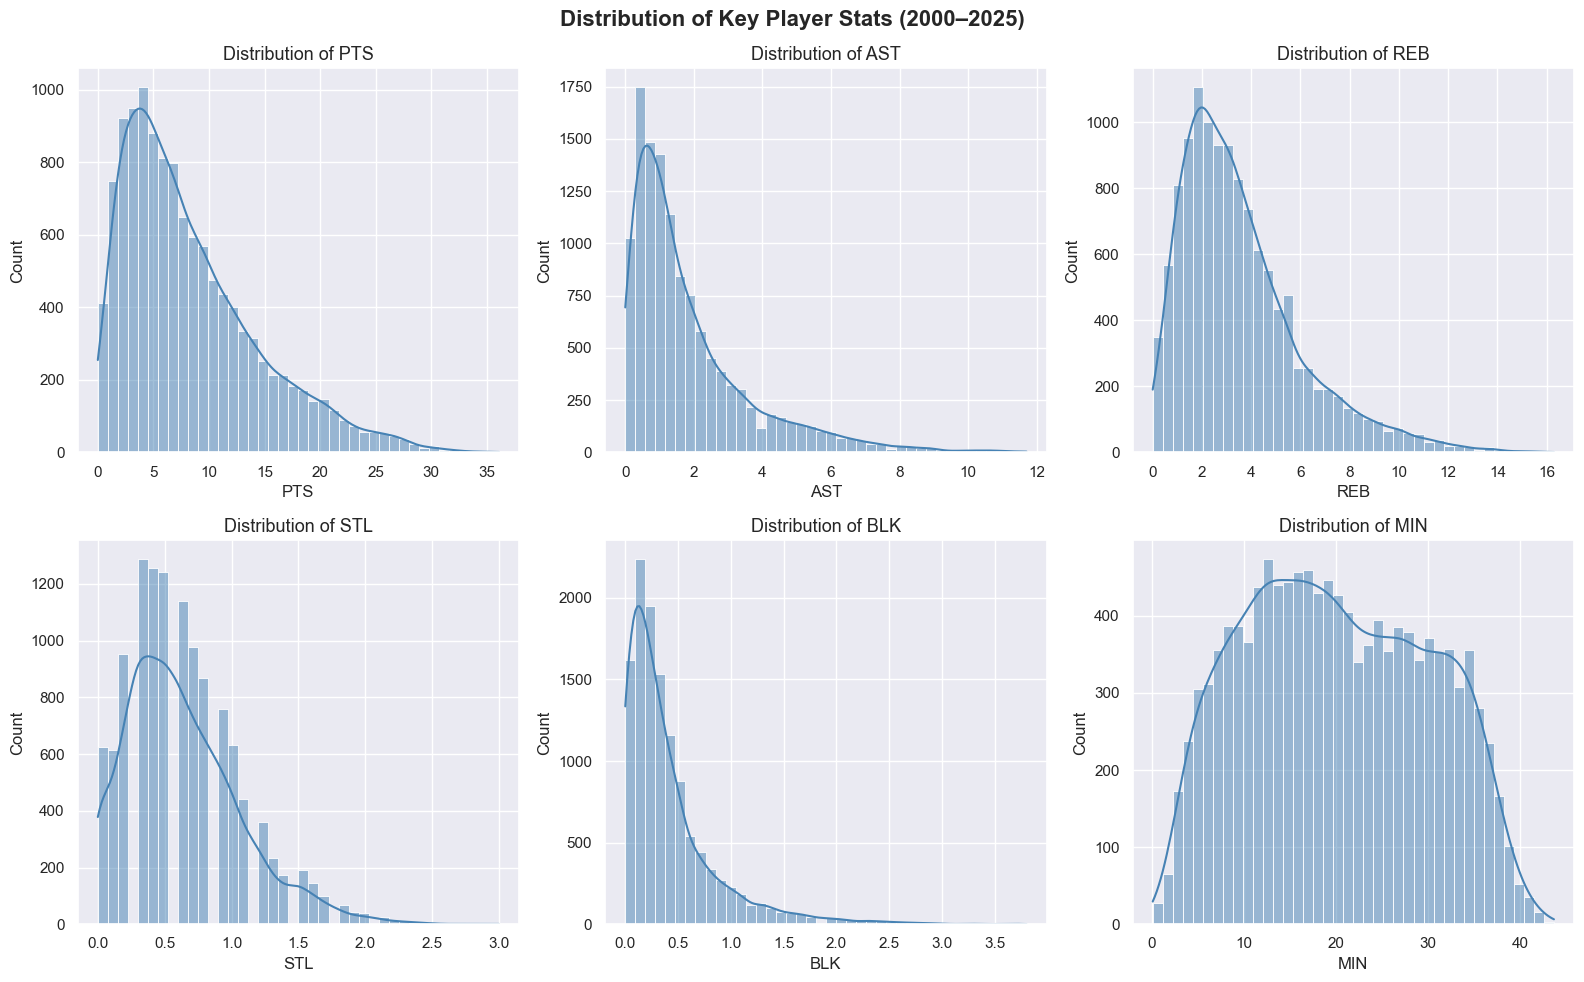

In [16]:
# ---------------- DISTRIBUTION OF KEY PLAYER STATS ----------------
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cols = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'MIN']

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}', fontsize=13)
    ax.set_xlabel(col)

plt.suptitle('Distribution of Key Player Stats (2000–2025)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

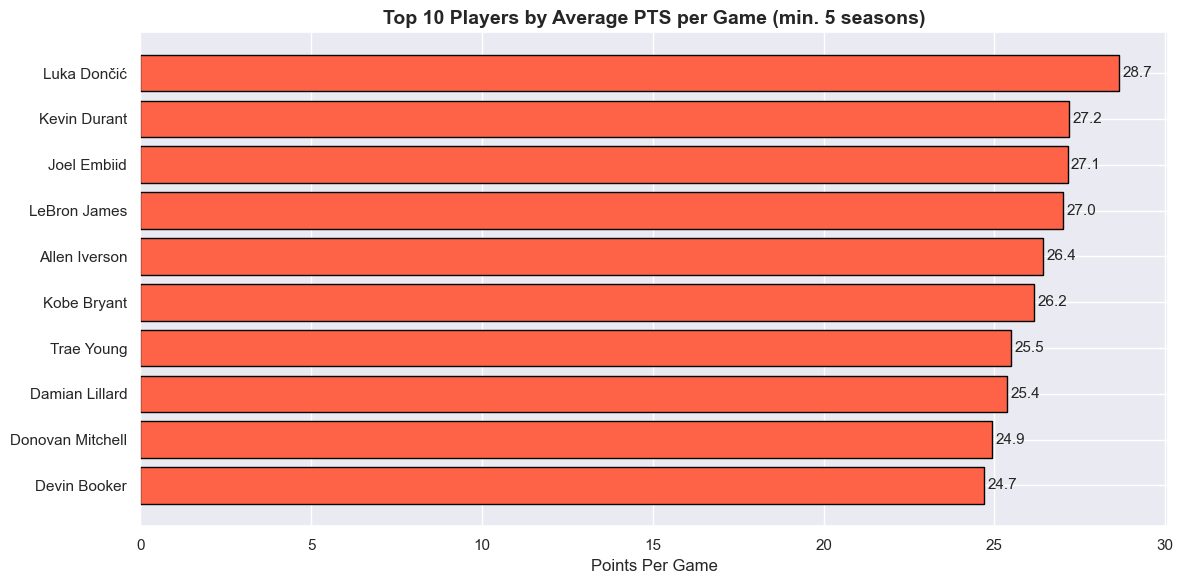

In [17]:
# ---------------- ANALYSIS OF TOP PLAYERS ----------------
player_avg = df.groupby('PLAYER_NAME').agg(
    PTS=('PTS', 'mean'),
    AST=('AST', 'mean'),
    REB=('REB', 'mean'),
    seasons=('SEASON', 'count')
).query('seasons >= 5').sort_values('PTS', ascending=False)

top10 = player_avg.head(10).reset_index()

plt.figure(figsize=(12, 6))
bars = plt.barh(top10['PLAYER_NAME'][::-1], top10['PTS'][::-1], color='tomato', edgecolor='black')
for bar, val in zip(bars, top10['PTS'][::-1]):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=11)
plt.title('Top 10 Players by Average PTS per Game (min. 5 seasons)', fontsize=14, fontweight='bold')
plt.xlabel('Points Per Game')
plt.tight_layout()
plt.savefig('eda_top10_scorers.png', dpi=150, bbox_inches='tight')
plt.show()

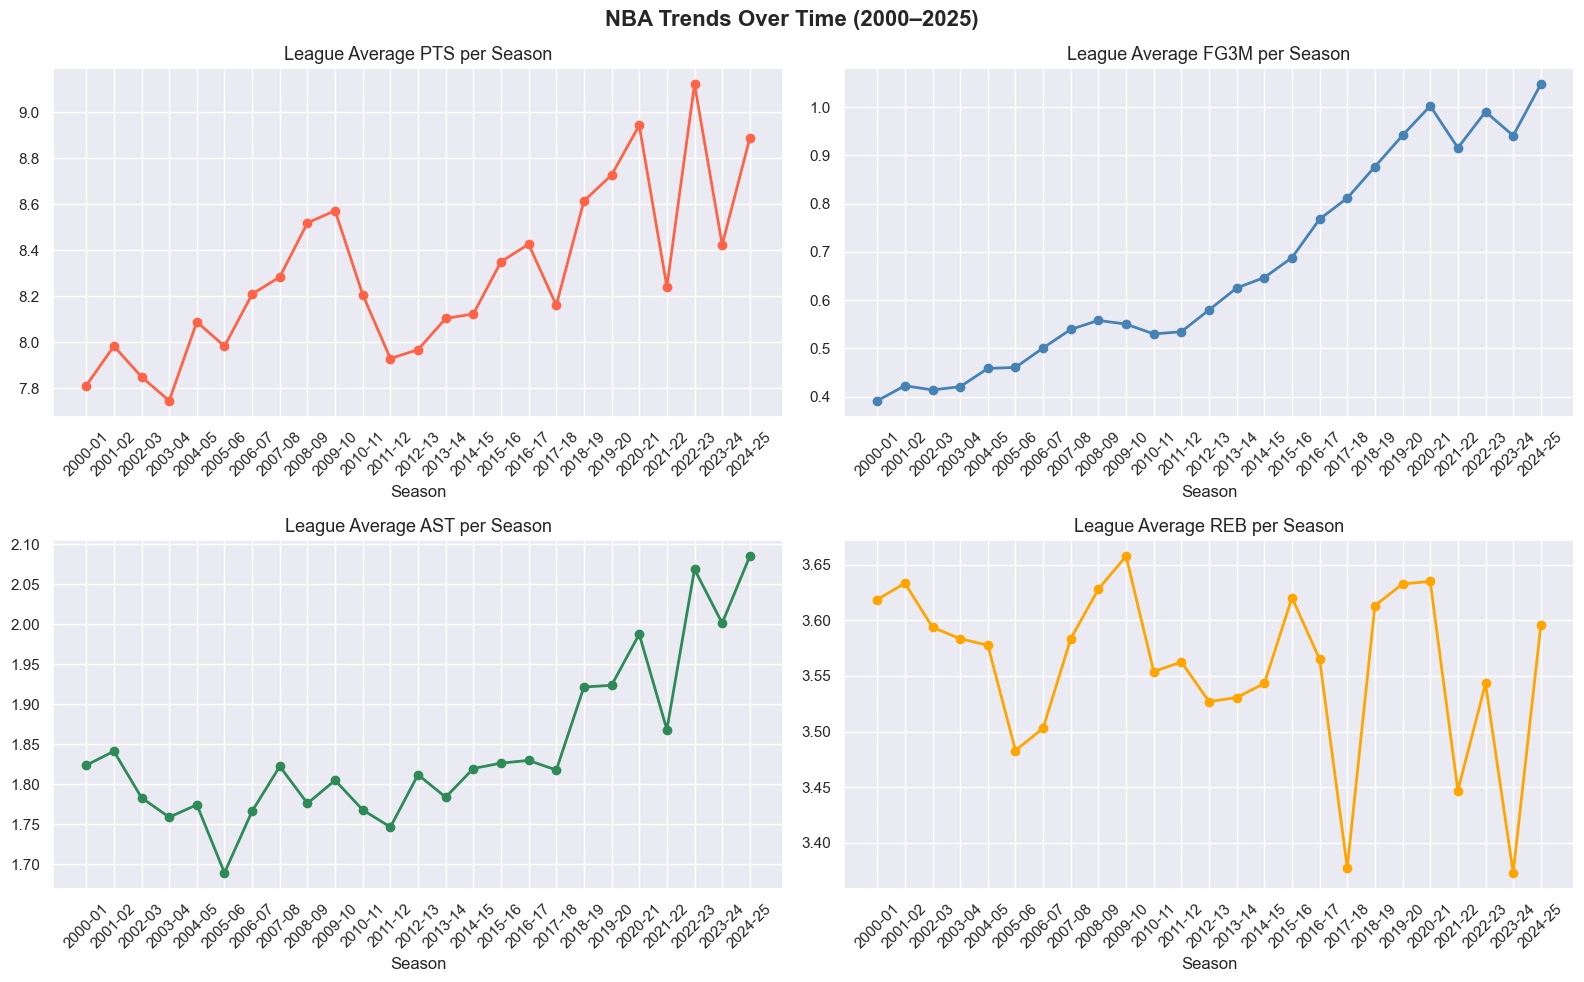

In [18]:
# ---------------- SUBPLOT GRID ----------------
season_avg = df.groupby('SEASON')[['PTS', 'FG3M', 'AST', 'REB']].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = ['PTS', 'FG3M', 'AST', 'REB']
colors = ['tomato', 'steelblue', 'seagreen', 'orange']

for ax, metric, color in zip(axes.flatten(), metrics, colors):
    ax.plot(season_avg['SEASON'], season_avg[metric], marker='o', color=color, linewidth=2)
    ax.set_title(f'League Average {metric} per Season', fontsize=13)
    ax.set_xlabel('Season')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('NBA Trends Over Time (2000–2025)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_trends.png', dpi=150, bbox_inches='tight')
plt.show()

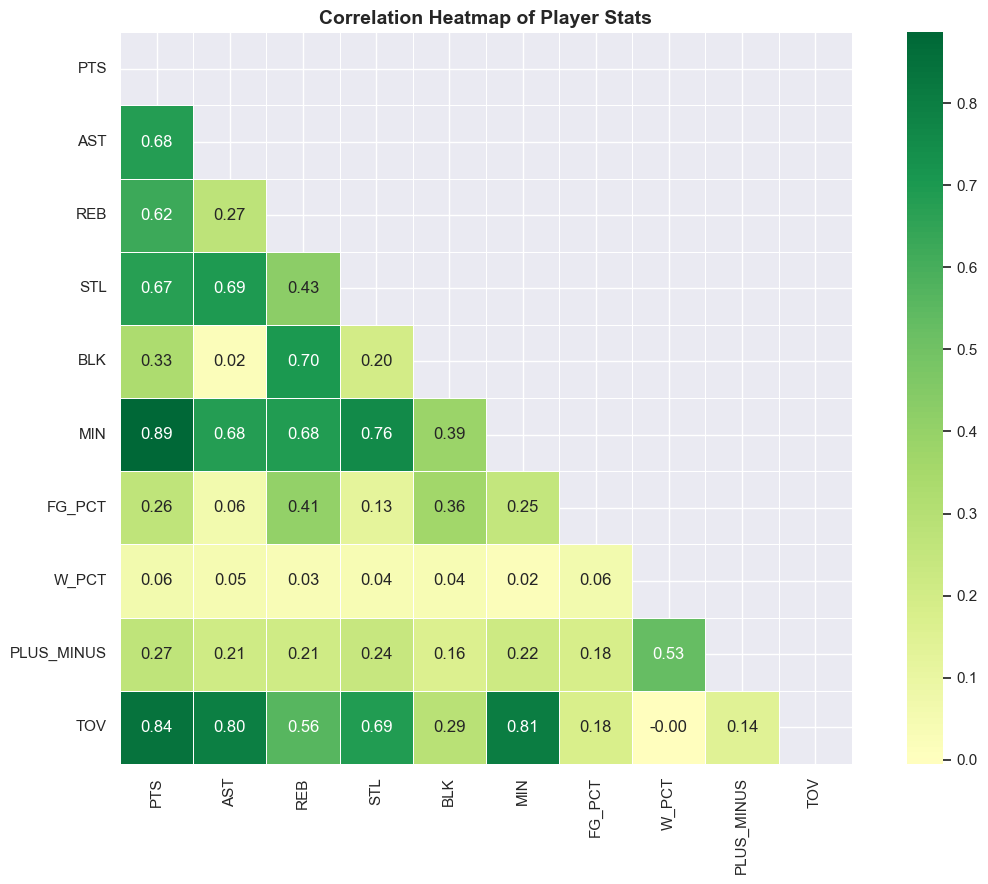

In [19]:
# ---------------- CORRELATION HEAT MAP ----------------
corr_cols = ['PTS', 'AST', 'REB', 'STL', 'BLK', 'MIN', 'FG_PCT', 'W_PCT', 'PLUS_MINUS', 'TOV']
corr = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Player Stats', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

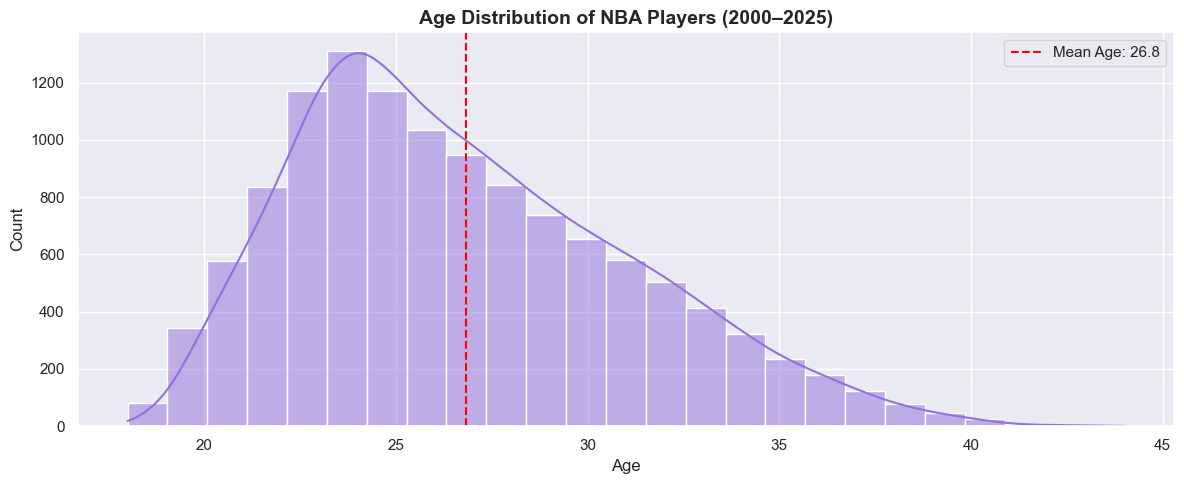

In [20]:
# ---------------- HISTOGRAM OF AGE DISTRIBUTION ----------------
plt.figure(figsize=(12, 5))
sns.histplot(df['AGE'].dropna(), bins=25, kde=True, color='mediumpurple')
plt.axvline(df['AGE'].mean(), color='red', linestyle='--', label=f'Mean Age: {df["AGE"].mean():.1f}')
plt.title('Age Distribution of NBA Players (2000–2025)', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.legend()
plt.tight_layout()
plt.savefig('eda_age_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# PART 5 - Hypothesis Testing & Time Series Analysis

In [21]:
# ---------------- TESTING FIRST HYPOTHESIS (HIGH SCORERS HAVE BETTER WIN PERCENTAGE) ----------------
df_h = df[df['GP'] >= 20].dropna(subset=['PTS', 'W_PCT'])

high_scorers = df_h[df_h['PTS'] >= 15]['W_PCT']
low_scorers  = df_h[df_h['PTS'] < 15]['W_PCT']

t_stat, p_value = stats.ttest_ind(high_scorers, low_scorers)

print('=' * 55)
print('HYPOTHESIS 1: High Scorers vs Win Percentage')
print('=' * 55)
print(f'High scorers (>=15 PPG): n={len(high_scorers)}, mean W%={high_scorers.mean():.3f}')
print(f'Low scorers  (<15 PPG):  n={len(low_scorers)},  mean W%={low_scorers.mean():.3f}')
print(f't-statistic : {t_stat:.4f}')
print(f'p-value     : {p_value:.6f}')
print()
if p_value < 0.05:
    print('RESULT: Reject H0 — High scorers have significantly better W_PCT (p < 0.05)')
else:
    print('RESULT: Fail to reject H0 — No significant difference found')

# Boxplot only
data_plot = pd.DataFrame({
    'W_PCT': pd.concat([high_scorers, low_scorers]),
    'Group': ['High Scorer (>=15 PPG)'] * len(high_scorers) + ['Low Scorer (<15 PPG)'] * len(low_scorers)
})

HYPOTHESIS 1: High Scorers vs Win Percentage
High scorers (>=15 PPG): n=1753, mean W%=0.525
Low scorers  (<15 PPG):  n=8412,  mean W%=0.488
t-statistic : 9.1507
p-value     : 0.000000

RESULT: Reject H0 — High scorers have significantly better W_PCT (p < 0.05)


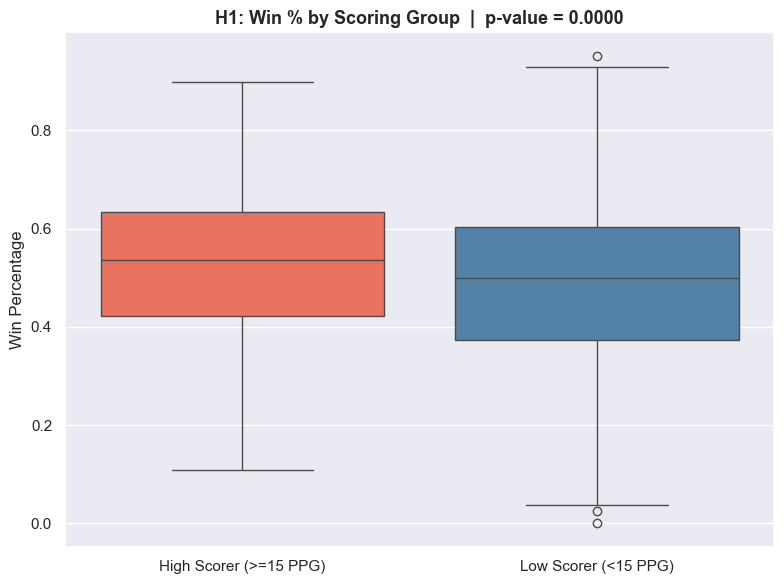

In [22]:
# ---------------- SUPPORTING PLOT FOR FIRST HYPOTHESIS ----------------
plt.figure(figsize=(8, 6))
sns.boxplot(x='Group', y='W_PCT', data=data_plot, palette=['tomato', 'steelblue'])
plt.title(f'H1: Win % by Scoring Group  |  p-value = {p_value:.4f}', fontsize=13, fontweight='bold')
plt.ylabel('Win Percentage')
plt.xlabel('')
plt.tight_layout()
plt.savefig('hyp1_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ---------------- TESTING SEC0ND HYPOTHESIS (IS THERE 3PT ERA IN NBA?) ----------------
early_era  = df[df['SEASON'].str[:4].astype(int) <= 2010]['FG3M'].dropna()
modern_era = df[df['SEASON'].str[:4].astype(int) >= 2015]['FG3M'].dropna()

t_stat2, p_value2 = stats.ttest_ind(modern_era, early_era)

print('=' * 55)
print('HYPOTHESIS 2: 3-Point Shooting — Early vs Modern Era')
print('=' * 55)
print(f'Early era  (2000-2010): n={len(early_era)},  mean FG3M={early_era.mean():.3f}')
print(f'Modern era (2015-2025): n={len(modern_era)}, mean FG3M={modern_era.mean():.3f}')
print(f't-statistic : {t_stat2:.4f}')
print(f'p-value     : {p_value2:.6f}')
print()
if p_value2 < 0.05:
    print('RESULT: Reject H0 — 3-point shooting significantly increased in modern era (p < 0.05)')
else:
    print('RESULT: Fail to reject H0 — No significant difference found')


data_h2 = pd.DataFrame({
    'FG3M': pd.concat([early_era, modern_era]),
    'Era': ['Early Era (2000-2010)'] * len(early_era) + ['Modern Era (2015-2025)'] * len(modern_era)
})

HYPOTHESIS 2: 3-Point Shooting — Early vs Modern Era
Early era  (2000-2010): n=4919,  mean FG3M=0.477
Modern era (2015-2025): n=5386, mean FG3M=0.903
t-statistic : 29.0015
p-value     : 0.000000

RESULT: Reject H0 — 3-point shooting significantly increased in modern era (p < 0.05)


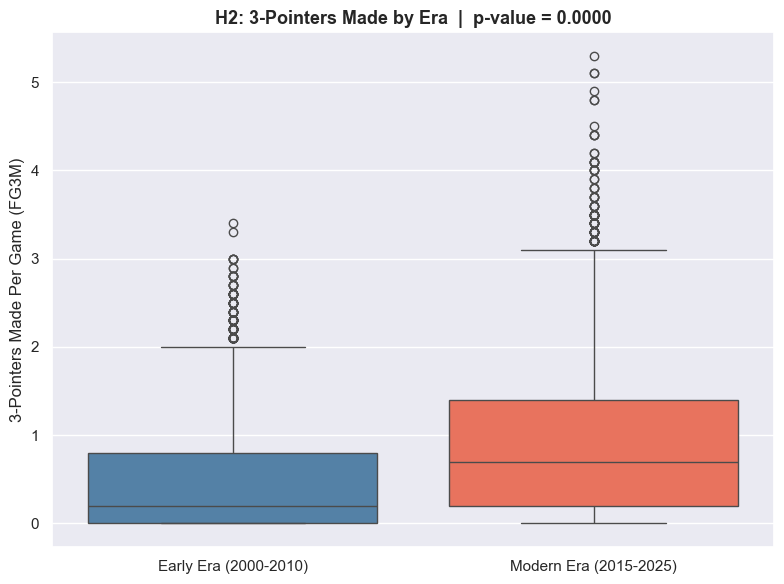

In [24]:
# ---------------- SUPPORTING PLOT FOR SECOND HYPOTHESIS ----------------
plt.figure(figsize=(8, 6))
sns.boxplot(x='Era', y='FG3M', data=data_h2, palette=['steelblue', 'tomato'])
plt.title(f'H2: 3-Pointers Made by Era  |  p-value = {p_value2:.4f}', fontsize=13, fontweight='bold')
plt.ylabel('3-Pointers Made Per Game (FG3M)')
plt.xlabel('')
plt.tight_layout()
plt.savefig('hyp2_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ---------------- TESTING THIRD HYPOTHESIS (RELATION BETWEEN SHOOTING EFFICIENCY AND +/-) ----------------
df_h3 = df[df['GP'] >= 20].dropna(subset=['FG_PCT', 'PLUS_MINUS'])

efficient   = df_h3[df_h3['FG_PCT'] >= 0.50]['PLUS_MINUS']
inefficient = df_h3[df_h3['FG_PCT'] < 0.50]['PLUS_MINUS']

t_stat3, p_value3 = stats.ttest_ind(efficient, inefficient)

print('=' * 55)
print('HYPOTHESIS 3: Shooting Efficiency vs Plus/Minus')
print('=' * 55)
print(f'Efficient   (FG% >=50%): n={len(efficient)},  mean +/-={efficient.mean():.3f}')
print(f'Inefficient (FG% <50%):  n={len(inefficient)}, mean +/-={inefficient.mean():.3f}')
print(f't-statistic : {t_stat3:.4f}')
print(f'p-value     : {p_value3:.6f}')
print()
if p_value3 < 0.05:
    print('RESULT: Reject H0 — Efficient shooters have significantly better +/- (p < 0.05)')
else:
    print('RESULT: Fail to reject H0 — No significant difference found')

data_h3 = pd.DataFrame({
    'PLUS_MINUS': pd.concat([efficient, inefficient]),
    'Group': ['Efficient (FG% >=50%)'] * len(efficient) + ['Inefficient (FG% <50%)'] * len(inefficient)
})

HYPOTHESIS 3: Shooting Efficiency vs Plus/Minus
Efficient   (FG% >=50%): n=2006,  mean +/-=0.515
Inefficient (FG% <50%):  n=8159, mean +/-=-0.325
t-statistic : 12.0405
p-value     : 0.000000

RESULT: Reject H0 — Efficient shooters have significantly better +/- (p < 0.05)


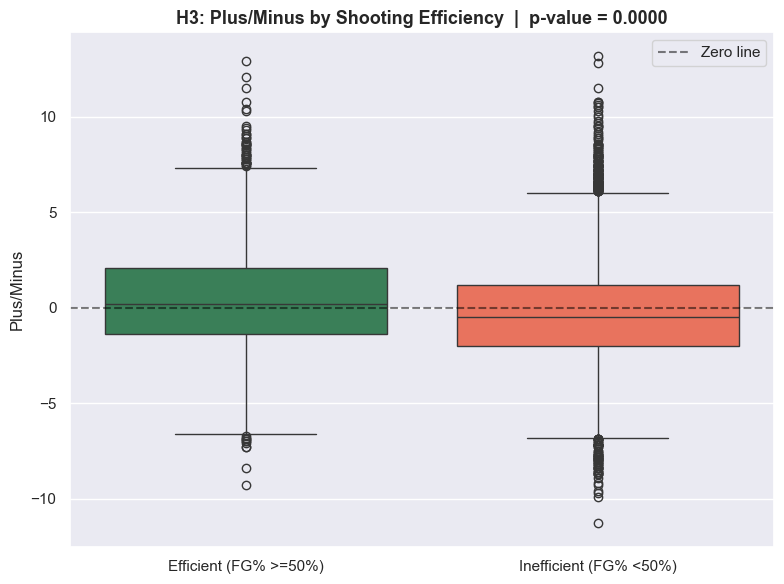

In [26]:
# ---------------- SUPPORTING PLOT FOR THIRD HYPOTHESIS ----------------
plt.figure(figsize=(8, 6))
sns.boxplot(x='Group', y='PLUS_MINUS', data=data_h3, palette=['seagreen', 'tomato'])
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Zero line')
plt.title(f'H3: Plus/Minus by Shooting Efficiency  |  p-value = {p_value3:.4f}', fontsize=13, fontweight='bold')
plt.ylabel('Plus/Minus')
plt.xlabel('')
plt.legend()
plt.tight_layout()
plt.savefig('hyp3_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

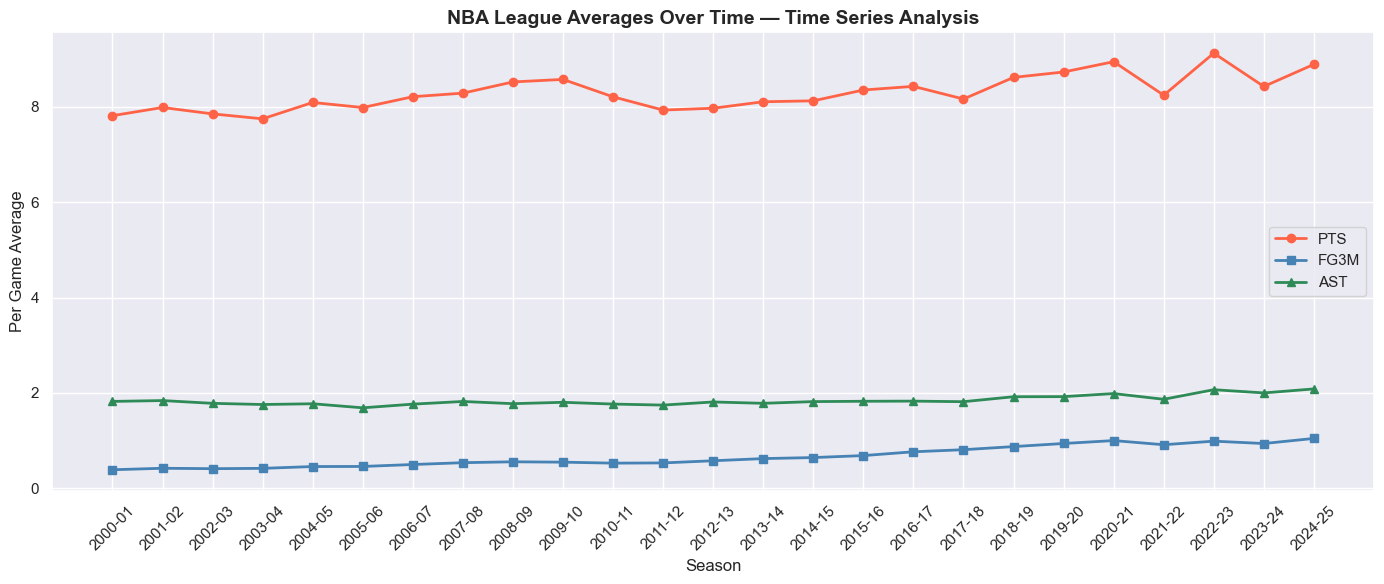

In [27]:
# ---------------- TIME SERIES ANALYSIS----------------
ts_data = df.groupby('SEASON')[['PTS', 'FG3M', 'AST']].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts_data['SEASON'], ts_data['PTS'],  marker='o', label='PTS',  color='tomato',    linewidth=2)
ax.plot(ts_data['SEASON'], ts_data['FG3M'], marker='s', label='FG3M', color='steelblue', linewidth=2)
ax.plot(ts_data['SEASON'], ts_data['AST'],  marker='^', label='AST',  color='seagreen',  linewidth=2)
ax.set_title('NBA League Averages Over Time — Time Series Analysis', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Per Game Average')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('timeseries_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ---------------- HYPOTHESIS SUMMARY ----------------
summary = pd.DataFrame({
    'Hypothesis': [
        'H1: High scorers (>=15 PPG) have better W%',
        'H2: Modern era has more 3-pointers (FG3M)',
        'H3: Efficient shooters (FG%>=50%) have better +/-'
    ],
    't-statistic': [round(t_stat, 4), round(t_stat2, 4), round(t_stat3, 4)],
    'p-value':     [round(p_value, 6), round(p_value2, 6), round(p_value3, 6)],
    'Result': [
        'Reject H0' if p_value  < 0.05 else 'Fail to reject H0',
        'Reject H0' if p_value2 < 0.05 else 'Fail to reject H0',
        'Reject H0' if p_value3 < 0.05 else 'Fail to reject H0',
    ]
})
print(summary.to_string(index=False))

                                       Hypothesis  t-statistic  p-value    Result
       H1: High scorers (>=15 PPG) have better W%       9.1507      0.0 Reject H0
        H2: Modern era has more 3-pointers (FG3M)      29.0015      0.0 Reject H0
H3: Efficient shooters (FG%>=50%) have better +/-      12.0405      0.0 Reject H0


# PART 6 - Predictive Modeling (Machine Learning)

In [29]:
# ---------------- PREDICTIVE MODEL (ML) ----------------
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

target_col = 'PTS'
numeric_df = df.select_dtypes(include=[np.number]).dropna(subset=[target_col])

X = numeric_df.drop(columns=[target_col]).fillna(0)
y = numeric_df[target_col]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("--- 6. Predictive Modeling (Baseline) ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


rf_predictions = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Random Forest R²: {rf_r2:.4f}")

Random Forest RMSE: 0.2493
Random Forest R²: 0.9983


In [30]:
# ---------------- ADVANCED MODEL ----------------
import xgboost as xgb

print("--- Bonus Opportunity: Advanced Model ---")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)


xgb_predictions = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print(f"XGBoost RMSE: {xgb_rmse:.4f}")
print(f"XGBoost R²: {xgb_r2:.4f}")
print("\n")


comparison_df = pd.DataFrame({
    'Model': ['Random Forest (Baseline)', 'XGBoost (Advanced)'],
    'RMSE (Lower = Better)': [rf_rmse, xgb_rmse],
    'R² (Closer to 1 = Better)': [rf_r2, xgb_r2]
})

print("--- Models comparison (Evaluation and Comparison) ---")
print(comparison_df.to_string(index=False))

XGBoost RMSE: 0.1747
XGBoost R²: 0.9992


--- Models comparison (Evaluation and Comparison) ---
                   Model  RMSE (Lower = Better)  R² (Closer to 1 = Better)
Random Forest (Baseline)               0.249327                   0.998309
      XGBoost (Advanced)               0.174665                   0.999170


In [35]:
print('Learning rate:', xgb_model.learning_rate)
print('n_estimators:', xgb_model.n_estimators)

Learning rate: 0.1
n_estimators: 100
